# KANVAS, Phase 7: Does the model generalize to users it has never seen?

Every AUC reported so far comes from a **random task-level split**, where tasks submitted by the same user can sit on both sides of the split. Phase 6's case audit found that KAAM's largest feature is substantially one user's recurring, repeatedly failing job. That makes the random-split numbers ambiguous: they may measure "recognise a known failing job" as much as "predict failure".

This phase measures the difference directly, with a split **grouped by submitting user**: no user's tasks appear in more than one of train, validation and test. It reports the result in whichever direction it comes out.

### Rules this phase follows

| Rule | How it is enforced |
|---|---|
| `user` is a split key, never a feature | It is recovered for grouping and statistics only; the model's inputs stay exactly `FEATURE_NAMES`, asserted in the split step and in `tests/test_user_robustness.py` |
| `user` never reaches an exported file | Nothing here writes it; the test suite re-checks the three publication CSVs |
| The partition is chosen on **label balance only** | `choose_partition` minimizes the worst gap between a part's failure rate and the dataset's, decided before any model is trained on any candidate |
| The dominant user is **not** dropped | Path A is a grouped split, not an exclusion: all 18,890 tasks stay in |
| Nothing is re-tuned | λ = 0.001, patience 15, 500-epoch cap, learning rate 0.01, LR at C = 0.1, MLP at (8, 6) and 0.03, threshold 0.5, all through the same functions the earlier phases used |

`data.py`, `bspline.py`, `model.py`, `training.py`, `baselines.py`, `ablation.py`, `case_studies.py` and `models/kaam_canonical.pt` are used unmodified. This phase adds `kanvas/robustness.py` and this notebook.

### One note on the comparison numbers

Step 6 compares against the random task-level split. It reuses **Phase 5's Table 1**, not Phase 4's, because Phase 4's baseline numbers were measured on the 2,310-row development sample: comparing against those would mix a change of sample size into a comparison that is supposed to isolate the change of split. Phase 5 re-ran both baselines on this exact 18,890-row dataset at the canonical split, and notebook 05 states that its table supersedes Phase 4's. Those values are read from `kanvas_benchmark_results.csv`, not retrained.

In [1]:
import os
import sys
import time
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler

import kanvas.robustness as rb
import kanvas.stability as st
from kanvas.case_studies import load_checkpoint
from kanvas.data import FEATURE_NAMES
from kanvas.model import KAAM
from kanvas.training import classification_metrics, predict_proba, train_kaam
from kanvas.utils import set_seed

%matplotlib inline
pd.set_option("display.width", 250)

# Chart style, unchanged from Phases 2-6 so every figure in the paper matches.
SURFACE, INK, INK_2, MUTED, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": BASELINE, "ytick.color": BASELINE, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.prop_cycle": cycler(color=[rb.RANDOM_COLOR, rb.GROUPED_COLOR]), "lines.linewidth": 2.0,
    "legend.frameon": False, "font.size": 10,
})

RAW_DIR = "../data/raw"
LARGE_CSV = "../data/processed/kanvas_features_large.csv"
PHASE5_BENCHMARK = "../data/processed/publication/kanvas_benchmark_results.csv"
CHECKPOINT = "../models/kaam_canonical.pt"
FIG_DIR = "../figures/phase7"
os.makedirs(FIG_DIR, exist_ok=True)

large = pd.read_csv(LARGE_CSV, index_col=["job_name", "task_name"])
X_large, y_large = large[FEATURE_NAMES], large["label"]
print(f"canonical dataset: {len(X_large):,} tasks, {int(y_large.sum()):,} failures "
      f"({y_large.mean():.2%}), {X_large.shape[1]} features")
print(f"frozen: lambda={st.LAMBDA_SMOOTH}, patience={st.PATIENCE}, max_epochs={st.MAX_EPOCHS}, lr={st.KAAM_LR}, "
      f"LR C={st.LR_C}, MLP {st.MLP_HIDDEN}@{st.MLP_LR}, threshold={st.THRESHOLD}")
print(f"partition attempts {len(rb.PARTITION_SEEDS)}, initialization seeds {rb.INIT_SEEDS}, "
      f"target shares {rb.PROPORTIONS}, balance gate {rb.BALANCE_TOLERANCE:.0%}")

canonical dataset: 18,890 tasks, 5,194 failures (27.50%), 10 features
frozen: lambda=0.001, patience=15, max_epochs=500, lr=0.01, LR C=0.1, MLP (8, 6)@0.03, threshold=0.5
partition attempts 20, initialization seeds [0, 1, 2], target shares {'train': 0.7, 'val': 0.15, 'test': 0.15}, balance gate 5%


## Step 1. Recover `user`, for grouping only

The feature matrix is indexed by `(job_name, task_name)`, and `pai_job_table` carries one row per job with the submitting `user` (already an opaque hash in the trace). Joining on `job_name` gives each task its submitter. This value is used for two things only: forming the groups, and the statistics in Step 2. It never joins the feature set and it is never written to a file.

In [2]:
user, join_report = rb.load_user_ids(RAW_DIR, X_large.index)

if join_report["unmatched"]:
    X_large = X_large.loc[user.notna()]
    y_large = y_large.loc[user.notna()]
    user = user.dropna()
    print(f"dropped {join_report['unmatched']:,} unmatched tasks; {len(X_large):,} tasks remain")
else:
    print("no tasks dropped: every task matched a user")
assert join_report["match rate"] >= 0.90, f"user join matched only {join_report['match rate']:.2%} of tasks"
assert "user" not in FEATURE_NAMES and list(X_large.columns) == FEATURE_NAMES

pai_job_table: 1,055,501 rows, 1,055,501 distinct jobs
join on job_name: 18,890 of 18,890 tasks matched a user (100.00%), 0 unmatched, 738 distinct users
no tasks dropped: every task matched a user


## Step 2. Who submits these tasks, and who fails

These numbers go into the paper's limitations section, so they are computed here from the trace rather than quoted from Phase 6's prose. Users are shown by rank label ("user 1" is the largest by task count); the raw hashes stay out of the notebook.

In [3]:
stats = rb.user_statistics(user, y_large)
display_cols = ["tasks", "failures", "failure_rate", "share of tasks", "share of failures"]
fmt = {"tasks": "{:,.0f}".format, "failures": "{:,.0f}".format, "failure_rate": "{:.2%}".format,
       "share of tasks": "{:.2%}".format, "share of failures": "{:.2%}".format}

print(f"TOTAL UNIQUE USERS: {len(stats):,}   (over {len(y_large):,} tasks and {int(y_large.sum()):,} failures)\n")
print("Top 5 users by task count:")
print(stats[display_cols].head(5).to_string(formatters=fmt))
print("\nTop 5 users by failure count:")
print(stats.sort_values("failures", ascending=False)[display_cols].head(5).to_string(formatters=fmt))

dominant = rb.dominant_user_summary(stats)
print(f"\nTHE SINGLE LARGEST USER ({dominant['largest by tasks']}), exact shares:")
print(f"  tasks    {dominant['tasks']:,} of {len(y_large):,}  =  {dominant['share of tasks']:.4%} of all tasks")
print(f"  failures {dominant['failures']:,} of {int(y_large.sum()):,}  =  {dominant['share of failures']:.4%} "
      f"of all failures")
print(f"  their own failure rate {dominant['failure rate']:.2%}, against {y_large.mean():.2%} for the dataset")
print(f"  also the largest user by failure count: {dominant['also largest by failures']}")

rest = user != stats.iloc[0]["user"]
print(f"\nEveryone else: {int(rest.sum()):,} tasks from {user[rest].nunique():,} users, "
      f"failure rate {y_large[rest].mean():.2%}")
top2 = stats.sort_values("failures", ascending=False).head(2)
print(f"The two largest failure sources together: {top2['share of failures'].sum():.2%} of all failures "
      f"from {top2['share of tasks'].sum():.2%} of tasks")

TOTAL UNIQUE USERS: 738   (over 18,890 tasks and 5,194 failures)

Top 5 users by task count:
       tasks failures failure_rate share of tasks share of failures
user 1 5,864    2,816       48.02%         31.04%            54.22%
user 2 1,171      127       10.85%          6.20%             2.45%
user 3   848       86       10.14%          4.49%             1.66%
user 4   664      551       82.98%          3.52%            10.61%
user 5   580       81       13.97%          3.07%             1.56%

Top 5 users by failure count:
       tasks failures failure_rate share of tasks share of failures
user 1 5,864    2,816       48.02%         31.04%            54.22%
user 4   664      551       82.98%          3.52%            10.61%
user 2 1,171      127       10.85%          6.20%             2.45%
user 3   848       86       10.14%          4.49%             1.66%
user 5   580       81       13.97%          3.07%             1.56%

THE SINGLE LARGEST USER (user 1), exact shares:
  tasks    

**These confirm Phase 6's figures rather than replacing them.** The largest user holds **31.04%** of tasks and **54.22%** of failures, which is what Phase 6 reported as 31.0% and 54.2%. Two details the summary did not carry:

- The same user is the largest by both measures, and their own failure rate is 48.02% against the dataset's 27.50%.
- The second-largest failure source, `user 4`, is small but extreme: 3.52% of tasks at an 82.98% failure rate, contributing another 10.61% of all failures. Two users therefore account for **64.82%** of every failure in the dataset.

That concentration is what makes a random task-level split generous: with one user on both sides of the split, a model can score well by learning that user's jobs.

## Step 3. A user-grouped 70/15/15 split

Each user's tasks move together. 20 candidate partitions are built with different random orders, and the one whose three failure rates sit closest to the dataset's is selected. **The criterion is label balance alone**, fixed here, before any model is trained on any candidate; no downstream performance enters the choice.

One structural point decides the shape of every candidate: the largest user holds 31% of the rows, which is more than an entire 15% part. That user cannot be in validation or test in any 70/15/15 grouped split, so they are in train by construction, in all 20 attempts. `robustness._assign` places such users first for exactly that reason; everything else is random order.

In [4]:
attempts, assignments = rb.grouped_partitions(user, y_large)
view = ["train share", "val share", "test share", "train failure rate", "val failure rate", "test failure rate",
        "worst failure-rate gap", "worst share gap", "users in test"]
print(f"20 candidate partitions (dataset failure rate {y_large.mean():.2%}); "
      f"selection = smallest 'worst failure-rate gap'\n")
print(attempts[view].to_string(formatters={c: "{:.1%}".format for c in view[:-1]} | {"users in test": "{:,.0f}".format}))

seed, role, balanced = rb.choose_partition(attempts, assignments, user)
print(f"\nCHOSEN: partition seed {seed}, worst failure-rate gap "
      f"{attempts.loc[seed, 'worst failure-rate gap']:.2%} "
      f"({'within' if balanced else 'OUTSIDE'} the {rb.BALANCE_TOLERANCE:.0%} gate), "
      f"worst share gap {attempts.loc[seed, 'worst share gap']:.2%}")

20 candidate partitions (dataset failure rate 27.50%); selection = smallest 'worst failure-rate gap'

               train share val share test share train failure rate val failure rate test failure rate worst failure-rate gap worst share gap users in test
partition seed                                                                                                                                            
0                    70.6%     14.5%      14.8%              26.0%            39.4%             23.0%                  11.9%            0.6%           361
1                    70.9%     14.6%      14.5%              29.9%            22.3%             21.1%                   6.4%            0.9%           348
2                    70.1%     15.0%      15.0%              29.3%            17.3%             29.0%                  10.2%            0.1%           430
3                    70.2%     14.9%      14.9%              29.6%            21.8%             23.4%                   5.7

In [5]:
splits = rb.split_by_role(X_large, y_large, role)
X_tr, X_va, X_te, y_tr, y_va, y_te = splits
report = rb.split_report(splits, user, y_large)
print("The chosen user-grouped split:\n")
print(report.to_string(formatters={"tasks": "{:,.0f}".format, "share": "{:.1%}".format, "failures": "{:,.0f}".format,
                                   "failure rate": "{:.2%}".format, "users": "{:,.0f}".format,
                                   "gap vs dataset": "{:+.2%}".format}))

parts = {name: set(user.loc[part.index]) for name, part in zip(rb.ROLES, (X_tr, X_va, X_te))}
overlaps = {f"{a} & {b}": len(parts[a] & parts[b]) for a, b in (("train", "val"), ("train", "test"), ("val", "test"))}
print(f"\nusers shared between parts: {overlaps}  (all zero = the grouping holds)")
assert set(overlaps.values()) == {0}
print(f"every task kept: {len(X_tr) + len(X_va) + len(X_te):,} of {len(X_large):,} "
      f"(the dominant user is grouped, not dropped)")
print(f"the dominant user's tasks are all in: {sorted(role[user == stats.iloc[0]['user']].unique())}")

The chosen user-grouped split:

       tasks share failures failure rate users gap vs dataset
part                                                         
train 13,737 72.7%    3,977       28.95%   101         +1.45%
val    2,578 13.6%      619       24.01%   332         -3.49%
test   2,575 13.6%      598       23.22%   305         -4.27%

users shared between parts: {'train & val': 0, 'train & test': 0, 'val & test': 0}  (all zero = the grouping holds)
every task kept: 18,890 of 18,890 (the dominant user is grouped, not dropped)
the dominant user's tasks are all in: ['train']


**The chosen partition is balanced on labels and close to 70/15/15.** Its three failure rates are 28.95% / 24.01% / 23.22% against the dataset's 27.50%, so the worst gap is 4.27 points, inside the 5-point gate. Row shares are 72.7 / 13.6 / 13.6, within 2.7 points of target. Test holds 2,575 tasks from **305 users the model never sees in training**.

The residual gap matters when reading the numbers below: the grouped test set's base rate (23.22%) is about four points lower than the canonical test set's (27.49%), because the failure-heavy users are large and land in train. AUC is not affected by a base-rate shift in the way accuracy and F1 are, which is why AUC carries the comparison here.

## Step 4. KAAM on the grouped split, three initializations

Same training function the canonical run used, same fixed settings, the input scaling refitted on this split's training tasks alone. Only the weight-initialization seed varies.

In [6]:
t0 = time.perf_counter()
kaam_table, kaam_fitted = rb.train_kaam_seeds(splits)
print(f"  [{time.perf_counter() - t0:.0f}s]\n")
print(kaam_table.to_string(formatters={"test AUC": "{:.4f}".format, "test accuracy": "{:.4f}".format,
                                       "test F1": "{:.4f}".format, "best epoch": "{:.0f}".format,
                                       "val BCE": "{:.4f}".format, "seconds": "{:.0f}".format}))
for metric in ("test AUC", "test accuracy", "test F1"):
    print(f"{metric}: mean {kaam_table[metric].mean():.4f} ± {kaam_table[metric].std(ddof=1):.4f} (std over "
          f"{len(kaam_table)} seeds)")
print(f"\nfor comparison, the canonical random-split run: test AUC 0.7520, accuracy 0.8095, F1 0.5755, "
      f"restored epoch 500")
print(f"majority-class accuracy on this test set (flag nothing): {1 - y_te.mean():.4f}")

  init seed 0: test AUC 0.4074  acc 0.7678  F1 0.0000  (best epoch 14, 5s)


  init seed 1: test AUC 0.4889  acc 0.7678  F1 0.0000  (best epoch 11, 3s)


  init seed 2: test AUC 0.4643  acc 0.7678  F1 0.0000  (best epoch 13, 4s)
  [12s]

          test AUC test accuracy test F1 best epoch val BCE seconds
init seed                                                          
0           0.4074        0.7678  0.0000         14  0.5608       5
1           0.4889        0.7678  0.0000         11  0.5558       3
2           0.4643        0.7678  0.0000         13  0.5583       4
test AUC: mean 0.4535 ± 0.0418 (std over 3 seeds)
test accuracy: mean 0.7678 ± 0.0000 (std over 3 seeds)
test F1: mean 0.0000 ± 0.0000 (std over 3 seeds)

for comparison, the canonical random-split run: test AUC 0.7520, accuracy 0.8095, F1 0.5755, restored epoch 500
majority-class accuracy on this test set (flag nothing): 0.7678


**KAAM does not transfer.** Test AUC is 0.4535 ± 0.0418 across the three seeds, against 0.7520 on the random split. Every run sits at or below chance. F1 is exactly 0.0000 in all three: at the 0.5 threshold the model flags nothing at all, and its 0.7678 accuracy is precisely the majority-class rate.

Two things in that table deserve attention before the baselines:

- **The runs stop after 11 to 14 epochs**, where the canonical run used all 500. Validation loss, measured on users the model never trains on, stops improving almost immediately.
- **The seed spread is 0.0418**, where Phase 5 measured 0.0001 for initialization on the random split. A barely-trained model is far more sensitive to where it started.

In [7]:
print("Where validation loss bottomed, and what it did afterwards:\n")
print(rb.training_trajectory(kaam_fitted).to_string(
    formatters={"epochs run": "{:.0f}".format, "best epoch": "{:.0f}".format, "val BCE at epoch 1": "{:.4f}".format,
                "best val BCE": "{:.4f}".format, "val BCE at the last epoch run": "{:.4f}".format}))

Where validation loss bottomed, and what it did afterwards:

          epochs run best epoch val BCE at epoch 1 best val BCE val BCE at the last epoch run  early stopped
init seed                                                                                                   
0                 29         14             0.6451       0.5608                        0.5744           True
1                 26         11             0.6346       0.5558                        0.5756           True
2                 28         13             0.6541       0.5583                        0.5756           True


## Step 5. The same split, both baselines

If the collapse were about KAAM's additive structure, a linear model and a black-box network on the same split would behave differently. Both come from `baselines.py` unchanged, at their fixed Phase 4 settings.

In [8]:
baseline_table, baseline_fitted = rb.run_baselines(splits)
print()
print(baseline_table.to_string(formatters={"test AUC": "{:.4f}".format, "test accuracy": "{:.4f}".format,
                                           "test F1": "{:.4f}".format, "parameters": "{:,.0f}".format,
                                           "seconds": "{:.2f}".format}))

  LR  : test AUC 0.4193  acc 0.7639  F1 0.0816  (11 parameters, 0.06s)
  MLP : test AUC 0.4025  acc 0.7678  F1 0.0000  (149 parameters, 0.18s)

      test AUC test accuracy test F1 parameters seconds
model                                                  
LR      0.4193        0.7639  0.0816         11    0.06
MLP     0.4025        0.7678  0.0000        149    0.18


**Both baselines collapse too, and further than KAAM.** Logistic regression reaches 0.4193 and the capacity-matched MLP 0.4025, against 0.7346 and 0.7558 on the random split. Logistic regression is the informative one: 11 parameters, no early stopping, no spline grid, fitted to convergence. It still lands below chance. **Whatever is happening is a property of the data and the task, not of KAAM's architecture or its training loop.**

## Step 6. The comparison table

Random-split numbers are read from Phase 5's exported Table 1, not retrained. Grouped-split numbers come from Steps 4 and 5. The paired bootstrap then compares KAAM's grouped models with the canonical model **on the tasks that are test tasks under both splits** — rows neither model was trained on, which is the only comparison in which both are honest. Same method as Phases 4 to 6: 2,000 resamples, seed 0.

In [9]:
phase5 = pd.read_csv(PHASE5_BENCHMARK).set_index("model")
random_metrics = {name: {"test AUC": float(phase5.loc[name, "AUC"]),
                         "test accuracy": float(phase5.loc[name, "accuracy"])} for name in ("KAAM", "LR", "MLP")}
print("Phase 5's canonical random-split numbers, as exported (reused, not retrained):")
for name, metrics in random_metrics.items():
    print(f"  {name:<4s} AUC {metrics['test AUC']:.10f}  accuracy {metrics['test accuracy']:.10f}")

comparison = rb.comparison_table(random_metrics, kaam_table, baseline_table)
print(f"\nCOMPARISON TABLE  ({len(comparison)} rows = 2 split types x 3 models)\n")
print(comparison.to_string(formatters={"test AUC": "{:.4f}".format, "AUC std": lambda v: "-" if pd.isna(v) else f"{v:.4f}",
                                       "test accuracy": "{:.4f}".format, "runs": "{:.0f}".format}))
print("\nChange from the random task-level split to the user-grouped split:\n")
print(rb.auc_drop(comparison).to_string(formatters={c: "{:+.4f}".format if "change" in c else "{:.4f}".format
                                                    for c in rb.auc_drop(comparison).columns}))

Phase 5's canonical random-split numbers, as exported (reused, not retrained):
  KAAM AUC 0.7519987881  accuracy 0.8094565984
  LR   AUC 0.7345823612  accuracy 0.7935779817
  MLP  AUC 0.7557705462  accuracy 0.8151023289

COMPARISON TABLE  (6 rows = 2 split types x 3 models)

                              test AUC AUC std test accuracy runs
split                   model                                    
random task-level split KAAM    0.7520     NaN        0.8095    1
                        LR      0.7346     NaN        0.7936    1
                        MLP     0.7558     NaN        0.8151    1
user-grouped split      KAAM    0.4535  0.0418        0.7678    3
                        LR      0.4193     NaN        0.7639    1
                        MLP     0.4025     NaN        0.7678    1

Change from the random task-level split to the user-grouped split:

      random split AUC grouped split AUC AUC change random split accuracy grouped split accuracy accuracy change
model         

In [10]:
canonical, canonical_ranges, canonical_splits, checkpoint = load_checkpoint(CHECKPOINT, LARGE_CSV)
print(f"loaded the canonical model from {os.path.normpath(CHECKPOINT)} "
      f"(test AUC {checkpoint['metrics']['test_auc']:.6f}, split random_state "
      f"{checkpoint['rule']['split_random_state']}, init seed {checkpoint['rule']['init_seed']})")

paired = rb.paired_vs_canonical(kaam_fitted, canonical, canonical_ranges, X_large, y_large,
                                canonical_splits[2].index)
print("\nPaired bootstrap on the tasks held out by BOTH splits (grouped KAAM - canonical KAAM):\n")
print(paired.to_string(formatters={"shared test tasks": "{:,.0f}".format, "shared failures": "{:,.0f}".format,
                                   "grouped AUC": "{:.4f}".format, "canonical AUC": "{:.4f}".format,
                                   "AUC difference": "{:+.4f}".format, "95% CI low": "{:+.4f}".format,
                                   "95% CI high": "{:+.4f}".format}))
excludes = (~paired["CI includes 0"].astype(bool)).sum()
print(f"\n{excludes} of {len(paired)} intervals exclude zero; every difference is negative "
      f"(mean {paired['AUC difference'].mean():+.4f})")

loaded the canonical model from ..\models\kaam_canonical.pt (test AUC 0.751999, split random_state 42, init seed 0)



Paired bootstrap on the tasks held out by BOTH splits (grouped KAAM - canonical KAAM):

          shared test tasks shared failures grouped AUC canonical AUC AUC difference 95% CI low 95% CI high  CI includes 0
init seed                                                                                                                 
0                       415              97      0.3813        0.5840        -0.2027    -0.2907     -0.1119          False
1                       415              97      0.5344        0.5840        -0.0497    -0.1151     +0.0217           True
2                       415              97      0.4852        0.5840        -0.0988    -0.1818     -0.0201          False

2 of 3 intervals exclude zero; every difference is negative (mean -0.1171)


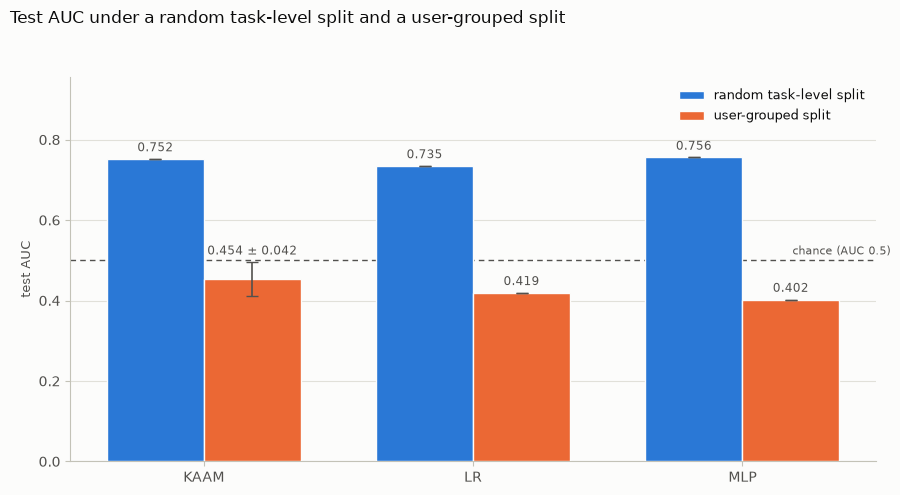

In [11]:
fig = rb.plot_split_comparison(comparison)
fig.suptitle("Test AUC under a random task-level split and a user-grouped split", x=0.005, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(f"{FIG_DIR}/split_comparison_auc.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the table.** The drop is large, it is shared by all three models, and it takes every one of them to chance or below:

| Model | Random split | User-grouped split | Change |
|---|---|---|---|
| KAAM | 0.7520 | 0.4535 ± 0.0418 | **−0.2985** |
| Logistic regression | 0.7346 | 0.4193 | **−0.3153** |
| MLP | 0.7558 | 0.4025 | **−0.3533** |

Accuracy barely moves (0.8095 → 0.7678 for KAAM), which is the trap in reporting accuracy on an imbalanced task: 0.7678 is exactly what flagging nothing scores on this test set.

**The paired comparison separates two different things.** On the 415 tasks held out by both splits, the canonical model scores 0.5840, far below its 0.7520 headline. So roughly 0.17 of the fall is the *population*: tasks from these smaller users are simply harder to rank, whoever is asking. The grouped models then score 0.3813, 0.5344 and 0.4852 on those same tasks, a further −0.20, −0.05 and −0.10, with two of the three intervals excluding zero. That remainder is the part attributable to never having seen the user before.

## Step 7. What happened to `plan_cpu`'s curve

`plan_cpu` is the feature Phase 6 traced back to one user's recurring job, and the one that carries about 29% of KAAM's importance on the random split. Both curves are drawn over the canonical training window and centered there, so only shape differs.

                                     curve range  max |dphi| vs random task-level split (canonical)  mean |dphi| vs random task-level split (canonical)  shape correlation vs random task-level split (canonical)
model                                                                                                                                                                                                            
random task-level split (canonical)        2.017                                              0.000                                               0.000                                                     1.000
user-grouped split (seed 0)                0.384                                              1.160                                               0.348                                                     0.615


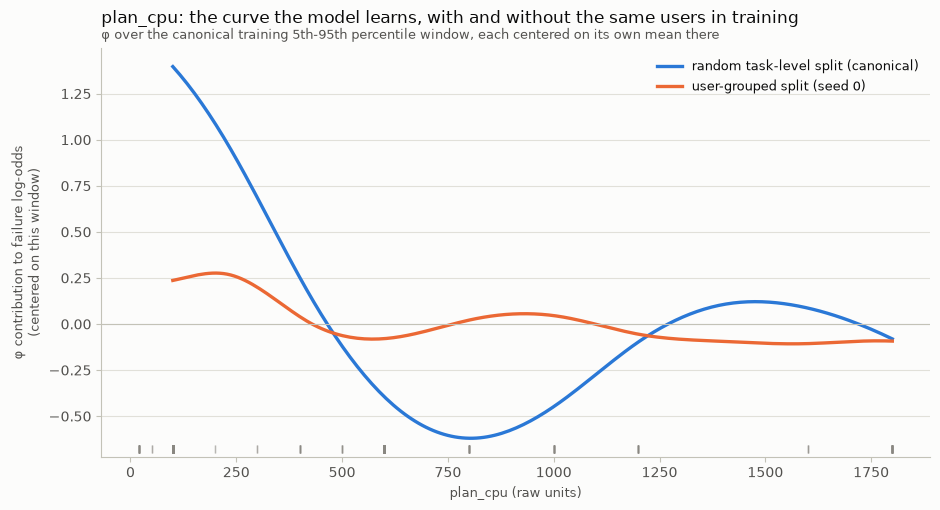

In [12]:
curves, curve_summary = rb.curve_overlay(
    {"random task-level split (canonical)": (canonical, canonical_ranges),
     "user-grouped split (seed 0)": (kaam_fitted[0]["model"], kaam_fitted[0]["result"].feature_ranges)},
    "plan_cpu", canonical_splits[0])
print(curve_summary.to_string(float_format="{:.3f}".format))

fig = rb.plot_curve_overlay(
    curves, "plan_cpu",
    colors={"random task-level split (canonical)": rb.RANDOM_COLOR, "user-grouped split (seed 0)": rb.GROUPED_COLOR},
    title="plan_cpu: the curve the model learns, with and without the same users in training",
    subtitle="φ over the canonical training 5th-95th percentile window, each centered on its own mean there",
    rug=canonical_splits[0]["plan_cpu"].sample(600, random_state=0))
fig.savefig(f"{FIG_DIR}/plan_cpu_curve_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

**The curve is flattened, not merely shifted.** On the random split, `plan_cpu` swings 2.02 log-odds across the window: a steep, confident statement that small CPU requests are much riskier. Trained on the grouped split, the same feature swings 0.38 log-odds, about a fifth as much, and the shapes correlate at only 0.61 with a largest gap of 1.16 log-odds.

The direct reading is that the steep curve does not survive the removal of same-user training data. Validation loss on held-out users starts rising after about a dozen epochs, which is the point at which the curve would have to steepen to fit the training users. The model is stopped before it gets there, so what the random split presents as the strongest relationship in the data is, on unseen users, a relationship the model cannot afford to learn.

## Why: the strongest feature means opposite things for different users

A drop this large deserves a mechanism rather than an assertion. The three checks below use the split already chosen and change nothing about it.

In [13]:
print("1. The same feature, in each part of the grouped split:\n")
signal = rb.signal_by_part(splits)
print(signal.to_string(formatters={"tasks at plan_cpu=100": "{:,.0f}".format, "their failure rate": "{:.1%}".format,
                                   "every other task's failure rate": "{:.1%}".format,
                                   "part failure rate": "{:.1%}".format,
                                   "AUC of -1 x plan_cpu alone": "{:.4f}".format}))

1. The same feature, in each part of the grouped split:

      tasks at plan_cpu=100 their failure rate every other task's failure rate part failure rate AUC of -1 x plan_cpu alone
part                                                                                                                       
train                 2,401              80.4%                           18.1%             29.0%                     0.7391
val                     164              23.8%                           24.0%             24.0%                     0.4501
test                     90              34.4%                           22.8%             23.2%                     0.4449


In [14]:
print("2. Diagnostic: the same run with early stopping disabled (patience = the epoch cap).")
print("   The restored weights are identical either way, since the loop always restores the best-validation")
print("   epoch. This run exists only to show what validation loss does if training continues.\n")
set_seed(rb.INIT_SEEDS[0])
probe = KAAM(FEATURE_NAMES, st.UNIT_RANGES, num_knots=st.NUM_KNOTS, spline_order=st.SPLINE_ORDER)
probe_result = train_kaam(probe, X_tr, y_tr, X_va, y_va, lambda_smooth=st.LAMBDA_SMOOTH, patience=st.MAX_EPOCHS,
                          max_epochs=st.MAX_EPOCHS, lr=st.KAAM_LR, verbose=False)
history = probe_result.history["val_loss"]
print(f"   best validation BCE {min(history):.4f} at epoch {probe_result.best_epoch}; "
      f"by epoch {len(history)} it has risen to {history[-1]:.4f}")
probe_auc = classification_metrics(y_te.to_numpy(), predict_proba(probe, X_te, probe_result.feature_ranges),
                                   st.THRESHOLD)["auc"]
print(f"   test AUC of the restored weights {probe_auc:.4f} (the same weights the Step 4 run restored)")

2. Diagnostic: the same run with early stopping disabled (patience = the epoch cap).
   The restored weights are identical either way, since the loop always restores the best-validation
   epoch. This run exists only to show what validation loss does if training continues.



   best validation BCE 0.5608 at epoch 14; by epoch 500 it has risen to 0.6310
   test AUC of the restored weights 0.4074 (the same weights the Step 4 run restored)


In [15]:
print("3. Would another partition have told a different story? (a check, not a selection:")
print("   the partition was already chosen in Step 3 on label balance)\n")
robustness_check = rb.partition_robustness(X_large, y_large, attempts, assignments, user, seed)
print()
print(robustness_check.to_string(formatters={"test tasks": "{:,.0f}".format, "test failure rate": "{:.2%}".format,
                                             "test AUC": "{:.4f}".format, "test accuracy": "{:.4f}".format,
                                             "test F1": "{:.4f}".format, "best epoch": "{:.0f}".format}))

3. Would another partition have told a different story? (a check, not a selection:
   the partition was already chosen in Step 3 on label balance)



  partition seed 17 (chosen): test AUC 0.4074  acc 0.7678  F1 0.0000  (best epoch 14)


  partition seed 4: test AUC 0.4485  acc 0.7582  F1 0.0000  (best epoch 13)


  partition seed 8: test AUC 0.4848  acc 0.7549  F1 0.0029  (best epoch 25)


  partition seed 13: test AUC 0.4163  acc 0.7777  F1 0.0000  (best epoch 13)

                chosen in step 3 test tasks test failure rate test AUC test accuracy test F1 best epoch
partition seed                                                                                         
17                          True      2,575            23.22%   0.4074        0.7678  0.0000         14
4                          False      2,717            24.18%   0.4485        0.7582  0.0000         13
8                          False      2,831            24.44%   0.4848        0.7549  0.0029         25
13                         False      2,753            22.23%   0.4163        0.7777  0.0000         13


**The mechanism is in the data, not the model.**

1. **The signal inverts.** Among the training users, a single-core request means an 80.4% failure rate against 18.1% for everything else: the strongest, cleanest pattern in the dataset. Among the validation users it means nothing at all (23.8% against 24.0%), and among the test users it is weak (34.4% against 22.8%). Ranking held-out tasks by the direction the model learned, smaller `plan_cpu` is riskier, scores **AUC 0.445 on test against 0.739 on train**. Below 0.5 means the learned ordering is slightly worse than reversing it.
2. **More training would make it worse.** Validation BCE bottoms at 0.5608 around epoch 14 and climbs to 0.6310 by epoch 500. Fitting the training users' pattern costs accuracy on new users from almost the first epoch.
3. **It is not this one partition.** Four different grouped partitions give test AUC 0.4074, 0.4485, 0.4848 and 0.4163. All below chance.

## Step 8. Limitations paragraph, for the paper

> **The model does not transfer to users it has never seen.** Every result in this paper up to this point uses a random task-level split, in which tasks from the same submitting user appear in both training and test. On the Alibaba PAI trace that matters more than it usually would: a single user accounts for 31.04% of the 18,890 tasks and 54.22% of all failures, and their recurring single-core job fails 88% of the time. Splitting instead by user, so that no user's tasks appear on both sides, test AUC falls from 0.7520 to 0.4535 ± 0.0418 for KAAM, from 0.7346 to 0.4193 for logistic regression, and from 0.7558 to 0.4025 for the capacity-matched MLP. All three land at or below chance, so the failure is a property of the data and the prediction task rather than of KAAM's additive structure: an 11-parameter linear model fitted to convergence, with no early stopping, fails in the same way. The mechanism is visible directly in the features. Among the training users, tasks requesting a single CPU core fail 80.4% of the time against 18.1% for all other tasks; among the held-out users the same tasks fail 34.4% against 22.8%, and ranking held-out tasks by the relationship the model learned scores an AUC of 0.445, slightly worse than reversing it. Validation loss measured on held-out users bottoms after 11 to 14 epochs and then rises steadily, so accuracy on known users is bought directly at the expense of accuracy on new ones, and `plan_cpu`'s learned curve flattens from a 2.02 log-odds swing to 0.38 when the same users are no longer in training. Part of the fall is population rather than generalization: on the tasks held out by both splits, the random-split model itself scores only 0.5840, and the grouped models fall a further 0.05 to 0.20 below that, with two of three paired bootstrap intervals excluding zero. The practical consequence is specific. These results support failure prediction for users whose earlier jobs are already in the training data, which is the realistic setting for a scheduler on an established fleet with recurring pipelines, and they do not support deploying the model against a new user's first submissions, where it would perform no better than chance. Any deployment claim beyond the first setting would need either training data from the target users or features that carry across them, and the ten request-and-telemetry features used here, dominated by request shape, demonstrably do not.

## Summary

| Question | Answer |
|---|---|
| **User join** | 100.00% of 18,890 tasks matched a user; 738 distinct users; no tasks dropped. |
| **Concentration** | The largest user: 31.04% of tasks, 54.22% of failures, 48.02% own failure rate. With `user 4` (82.98% failure rate), two users hold 64.82% of all failures. Phase 6's 31.0% / 54.2% reproduce exactly. |
| **Grouped partition** | Chosen on label balance alone from 20 candidates: failure rates 28.95 / 24.01 / 23.22% against the dataset's 27.50% (worst gap 4.27 points, inside the 5-point gate); shares 72.7 / 13.6 / 13.6%; 305 unseen users in test. The dominant user is in train by construction, not by choice. |
| **KAAM, grouped** | AUC 0.4535 ± 0.0418 over three seeds (0.4074 / 0.4889 / 0.4643), F1 0.0000, accuracy equal to the majority class. Runs stop after 11-14 epochs. |
| **Baselines, grouped** | Logistic regression 0.4193, MLP 0.4025. The collapse is not architecture-specific. |
| **Drop** | KAAM −0.2985, LR −0.3153, MLP −0.3533 in test AUC. |
| **Paired CI** | On the 415 tasks held out by both splits: −0.2027 [−0.2907, −0.1119], −0.0497 [−0.1151, +0.0217], −0.0988 [−0.1818, −0.0201]. Two of three exclude zero, all three negative. |
| **`plan_cpu` curve** | Flattened from a 2.02 log-odds swing to 0.38, shape correlation 0.61. |
| **Mechanism** | The 1-core signal inverts across user populations: AUC 0.739 on train, 0.445 on test for that feature alone. |

### What this changes

- **Phase 5's Table 1 keeps its meaning, but gains a scope.** It describes failure prediction for users already represented in training. That is a real and useful setting; it is not the same claim as "predicts task failure on this cluster".
- **The interpretability results are unaffected in kind.** `explain()` is still exact, the curves are still the model's own arithmetic, and Phase 6's audit is what found this. What changes is the reading of the `plan_cpu` curve: on the random split it describes one user's job, not a fleet-wide law.

### Open items

- **Path B, exclusion:** retrain with the dominant user removed entirely, to see what the remaining population supports. Deliberately out of scope here.
- **Features that carry across users:** the ten features are dominated by request shape. Telemetry-only or normalized-per-user features are the obvious candidates for a model meant to generalize.
- **A grouped-split threshold rule:** at 0.5 the grouped models flag nothing, so precision and recall are undefined in practice; a recall-target rule would have to be fitted on the grouped validation split.
- **Carried over:** the 500-epoch cap and the `plan_gpu` interaction hypothesis from Phases 5 and 6.